# 05 Topic Analysis

**Goal:** Explore the structure and content of semantic clusters across all transcript chunks.

This notebook covers:
- Loads `named_clustered_dataset.json` and builds a flat chunk-level DataFrame with cluster ID, cluster name, chunk label, sentiment, call type, and embeddings
- Cluster size distribution — chunks per cluster across all 20 clusters
- Top chunk labels per cluster and cluster-level content summaries
- Representative chunks per cluster — finds the 3 chunks closest to each cluster centroid using cosine similarity
- Worst-fit examples — finds chunks least similar to their cluster centroid to identify potential mislabelled or noisy chunks
- Manual inspection of specific clusters (0: Outage Communication, 2: Compliance Reporting, 16: Billing Discrepancies)
- Exports cluster 2 chunks to a JSON file for manual review
- UMAP visualisation — projects all chunk embeddings to 2D coloured by cluster, with numbered centroid annotations
- Intra-cluster cosine similarity box plots (Plotly) — shows the spread of pairwise similarity within each cluster
- Sankey diagram (Plotly) — maps top transcripts to top themes by chunk count
- Bar chart (Plotly) — cluster chunk counts and transcript counts across all themes
- Hierarchical dendrogram of cluster centroids using Ward linkage
- Cluster → topic flow Sankey — maps top 10 clusters to their top provided topics
- Sentiment heatmap — sentiment distribution (%) within each of the top 10 clusters, sorted by negative share


In [130]:
from pathlib import Path
import json
import re
import textwrap
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [109]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CLUSTERED_CHUNKS_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "clustered_chunks"
    / "named_clustered_dataset.json"
)

with open(CLUSTERED_CHUNKS_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

rows = []
for meeting in raw:
    for ch in meeting.get("semantic_chunks", []):
        rows.append({
            "meeting_id":               meeting["meeting_id"],
            "meeting_title":            meeting["meeting_metadata"]["title"],
            "chunk_id":                 ch["chunk_id"],
            "cluster_id":               ch.get("cluster_id"),
            "cluster_name":             ch.get("cluster_name"),
            "chunk_label":              ch.get("chunk_label"),
            "chunk_summary":            ch.get("chunk_summary"),
            "chunk_text":               ch.get("chunk_text"),
            "chunk_sentiment":          ch.get("chunk_sentiment"),
            "call_type":                ch.get("call_type"),
            "is_cross_domain":          ch.get("is_cross_domain"),
            "is_scaffolding":           ch.get("is_scaffolding"),
            "matched_provided_topics":  ch.get("matched_provided_topics"),
            "embedding":                ch.get("embedding"),
        })

df = pd.DataFrame(rows)
print(df.shape)
df.head(3)

(378, 14)


,meeting_id,meeting_title,chunk_id,cluster_id,cluster_name,chunk_label,chunk_summary,chunk_text,chunk_sentiment,call_type,is_cross_domain,is_scaffolding,matched_provided_topics,embedding
0,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_001,0,Outage Communication,Outage Overview,Team discusses current outage status and need for remediation plan.,"Megan Lawson: Alright, I think we're all on — Raj, Brian, can you both hear me okay?\nRaj Kapoor: Yeah, I'm here. Audio's good.\nBrian Cho: Yep, I'm on. Give me one sec, I'm just pulling up the incident doc.\nMegan Lawson: Sure, take your time. So, uh, the reason I wanted to get us together today — obviously we're still in the middle of this, day three of the outage window — I want to make sure we have a clear remediation plan and that we're all aligned before we send anything else externally.",neutral,internal_operational,False,False,[incident response],"[-0.0076064495369791985, -0.012960203923285007, -0.06597937643527985, 0.050067368894815445, -0.0010541838128119707, -0.01872098259627819, -0.026665721088647842, -0.013858544640243053, 0.05267244204878807, 0.02102707326412201, 0.03856760635972023, -0.004624257795512676, 0.03505675867199898, -0.006768764927983284, -0.04537932202219963, -0.014892270788550377, -0.03677992522716522, -0.016193699091672897, -0.023262815549969673, -0.01331480871886015, -0.026097029447555542, 0.03316730260848999, 0.008193066343665123, 0.018896527588367462, -0.07473023980855942, 0.021761421114206314, -0.013759930618107319, -0.014151482842862606, 0.050354186445474625, 0.044405072927474976, -0.07128036022186279, -0.028919680044054985, -0.03345244750380516, -0.026657909154891968, 0.031069861724972725, -0.01918422430753708, 0.026232782751321793, -0.033265918493270874, -0.05254150554537773, -0.07777867466211319, -0.02256813645362854, 0.013391067273914814, 0.09316838532686234, -0.04596003517508507, -0.046111881732940674, 0.010773962363600731, -0.03341313824057579, 0.005990170873701572, 0.0018527003703638911, 0.001660606823861599, 0.006686515640467405, 0.03951900079846382, -0.02643534354865551, -0.014447126537561417, 0.024054888635873795, -0.024936039000749588, -0.02005438506603241, 0.059701692312955856, -0.04530056565999985, -0.015825659036636353, 0.02813940867781639, 0.006123639177531004, 0.007597514893859625, -0.042446333914995193, 0.017701786011457443, 0.07745950669050217, -0.054710421711206436, -0.010185700841248035, -0.00701520498842001, 0.021843522787094116, -0.024086739867925644, 0.009063179604709148, -0.05217580497264862, -0.015887083485722542, 0.013404816389083862, -0.005374599248170853, -0.029010767117142677, 0.00849701277911663, -0.026547633111476898, 0.05524134635925293, -0.006116484757512808, 0.014189505018293858, 0.009376353584229946, -0.01240593008697033, -0.0015742836985737085, -0.014344466850161552, 0.03023669496178627, -6.910367665113881e-05, 0.020882397890090942, 0.01818186789751053, 0.013194647617638111, 0.037749603390693665, -0.008743333630263805, -0.0023906640708446503, 0.02733246609568596, 0.02889348194003105, -0.03209322318434715, -0.0013721499126404524, -0.024597574025392532, 0.04208908975124359, ...]"
1,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_002,0,Outage Communication,Root Cause Analysis,Agent explains the cascading failure and proposed fixes for the outage.,"Raj Kapoor: Yeah, agreed. I've been heads-down with the engineering team since Saturday and I think we have a pretty solid picture of the root cause at this point. Do you want me to just walk through it?\nMegan Lawson: Please, yeah. Go ahead.\nRaj Kapoor: Okay so — and Brian, let me know if the technical depth here is useful for you or if you want me to translate as I go — basically what we're looking at is a cascading failure in the event processing pipeline. The short version is we had a single point of failure in the event ingestion layer, and when that node went down, there was 

In [110]:
df.groupby(["cluster_id", "cluster_name"], dropna=False).size() \
  .sort_values(ascending=False) \
  .rename("count")

cluster_id  cluster_name                  
0           Outage Communication              99
2           Compliance Reporting              82
6           Compliance Enhancements           46
7           Follow-Up Commitments             44
3           Renewal Negotiation               35
1           Onboarding Process                13
19          Sprint Planning                    9
9           Incident Remediation               8
4           Competitive Insights               7
14          Service Performance Evaluation     7
18          Authentication Challenges          6
16          Billing Discrepancies              5
10          Alert Management Challenges        5
5           Audit Preparation                  4
8           Infrastructure Performance         2
17          Postmortem Analysis                2
11          Restore User Experience            1
12          Launch Readiness                   1
13          Spring Launch Impact               1
15          PDF Rendering 

In [111]:
for cid, grp in df.groupby("cluster_id", dropna=False):
    name = grp["cluster_name"].iloc[0] if pd.notna(cid) else "untriaged"
    top = Counter(grp["chunk_label"]).most_common(5)
    print(f"\n[{cid}] {name}  (n={len(grp)})")
    for lbl, c in top:
        print(f"   {c:2d}  {lbl}")


[0] Outage Communication  (n=99)
    5  Root Cause Analysis
    4  Incident Overview
    4  Platform Outage
    3  Service Outage
    3  Root Cause Investigation

[1] Onboarding Process  (n=13)
    3  Onboarding Introduction
    2  Onboarding Process
    2  Implementation Timeline
    1  ISO 27001 Introduction
    1  Current ISO Status

[2] Compliance Reporting  (n=82)
    3  Deployment Planning
    2  Access Control Review
    2  Audit Preparation
    2  Q2 Roadmap Planning
    2  Identity Management Discussion

[3] Renewal Negotiation  (n=35)
    4  Renewal Discussion
    2  Customer Communication
    2  Contract Renewal Discussion
    2  Renewal Concerns
    2  Contract Renewal

[4] Competitive Insights  (n=7)
    1  Competitive Positioning
    1  Product Launch Planning
    1  Adaptive MFA Policies
    1  Competitive Landscape
    1  Q1 Win-Loss Analysis

[5] Audit Preparation  (n=4)
    1  SOC 2 Audit Preparation
    1  Quarterly Planning
    1  Tech Debt Discussion
    1  SOC 2 

In [112]:
top10_ids = (
    df.dropna(subset=["cluster_id"])
      .groupby("cluster_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .index
      .tolist()
)

top10_ids

[0, 2, 6, 7, 3, 1, 19, 9, 4, 14]

In [113]:
def l2norm(v):
    n = np.linalg.norm(v)
    return v if n == 0 else v / n

def get_representative_chunks(cluster_id, n=3):
    """Return the n chunks closest to the cluster's centroid."""
    grp = df[df["cluster_id"] == cluster_id].copy()
    embs = np.stack([l2norm(np.array(e, dtype=np.float32))
                     for e in grp["embedding"]])
    centroid = l2norm(embs.mean(axis=0))
    grp["_sim_to_centroid"] = embs @ centroid
    return grp.sort_values("_sim_to_centroid", ascending=False).head(n)

get_representative_chunks(0, n=3)[
    ["meeting_id", "chunk_label", "chunk_text", "_sim_to_centroid"]
]

/var/folders/jf/7cvyp7b11r9gr1394g_p3mhm0000gn/T/ipykernel_75513/3924386745.py:11: RuntimeWarning: divide by zero encountered in matmul
  grp["_sim_to_centroid"] = embs @ centroid
/var/folders/jf/7cvyp7b11r9gr1394g_p3mhm0000gn/T/ipykernel_75513/3924386745.py:11: RuntimeWarning: overflow encountered in matmul
  grp["_sim_to_centroid"] = embs @ centroid
/var/folders/jf/7cvyp7b11r9gr1394g_p3mhm0000gn/T/ipykernel_75513/3924386745.py:11: RuntimeWarning: invalid value encountered in matmul
  grp["_sim_to_centroid"] = embs @ centroid


,meeting_id,chunk_label,chunk_text,_sim_to_centroid
69,01KQ351E141926AB7CAB668D,Incident Response,"Maria Santos: Grace, hi, thank you so much for jumping on this call with me today, I know your schedule is absolutely packed right now.\nGrace Yoon: Maria, I'm going to be honest with you, I almost didn't pick up.\nMaria Santos: I — okay, I understand that, and I want you to know I take that seriously.\nGrace Yoon: Do you have any idea what the last thirty-six hours have looked like for my team? We've had zero visibility into our threat monitoring since yesterday morning and I — I don't even know where to start.\nMaria Santos: I know, Grace, and I am so sorry. I've been following the incident updates internally and I wanted to get on a call with you specifically because Northstar is one of our most important customers and I didn't want you to feel like you were just getting a status page update.\nGrace Yoon: A status page update. Yeah, that's... that's exactly what we've been getting. Little green and yellow dots that don't tell me anything useful while my security team is flying blind in a healthcare environment, Maria.\nMaria Santos: You're right, that's not acceptable, and I'm not here to defend the communication, I'm here to — to actually talk through what happened and what we're doing about it.\nGrace Yoon: Okay. So what did happen? Because from where I'm sitting, Aegis Detect just... stopped. Six hours of nothing. No alerts, no event processing, nothing. And we didn't even get a proactive notification from you guys.\nMaria Santos: So, the engineering team has identified the root cause — there was a cascading failure in our event processing pipeline, um, essentially a single point of failure in the event ingestion layer that propagated across the system. It was not a breach, it was not a data loss event, but it did take down the monitoring pipeline.\nGrace Yoon: A single point of failure. In a security platform. That we are paying — Grace paused — that we are paying quite a lot of money for, I might add.\nMaria Santos: I understand how that sounds, and frankly it should not have been architected that way. I'm not going to sugarcoat it.\nGrace Yoon: Do you understand the regulatory exposure we have? We're a pharma company, we operate under HIPAA, we have audit obligations, and for six hours — six hours — I had no way to tell you whether something was happening on our network or not. If there had been an incident during that window, I would have no logs, no alerts, no evidence trail from your platform. None.\nMaria Santos: Grace, yes, and I want to be clear — our engineering team has confirmed that the event data itself was not lost, it was queued, and is being backfilled now. So your audit trail should be intact going back through the outage window.\nGrace Yoon: Should be. That's a very comforting phrase.\nMaria Santos: I hear the sarcasm and I — I deserved that. Let me get you a written confirmation of that from our engineering team today, not tomorrow, today.",0.882851
44,01KQ2331EFD78BF3B1CAB747,Product Outage,"Lisa Park: Okay, I think everyone's on now — Diana, can you hear us okay?\nDiana Reeves: Yeah, I'm here. Sorry, I was just — I had another call running over. Let's get into it.\nLisa Park: No worries. So, um, I wanted to get us all together because the inbound volume from customers this morning has been... it's been a lot.\nAisha Johnson: Yeah, same on the support side. We've had — Priya, you want to give the numbers?\nPriya Patel: Sure. So as of about thirty minutes ago we had logged forty-seven inbound tickets directly related to the Detect outage. That's just tickets — that doesn't count the calls, the Slack pings through shared channels, emails going directly to AMs.\nDiana Reeves: Forty-seven. Okay. And what's the breakdown in terms of severity? Like, are these mostly tier-one enterprise accounts or—\nPriya Patel: It's across the board honestly. We've got mid-market, we've got enterprise, we've got a couple of 

In [114]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
np.set_printoptions(threshold=np.inf, linewidth=200)

display(HTML("""
<style>
.jp-OutputArea-output pre,
div.output_area pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
}
.dataframe td, .dataframe th {
    white-space: normal !important;
    text-align: left !important;
    vertical-align: top !important;
    max-width: 600px;
}
</style>
"""))
print("Display settings applied.")

Display settings applied.


In [131]:
CLUSTER_TO_REVIEW = 2
WRAP_WIDTH = 100

def wrap_text(text, width=WRAP_WIDTH):
    if not text:
        return text
    wrapped_lines = []
    for line in text.split("\n"):
        if line.strip() == "":
            wrapped_lines.append("")
        else:
            wrapped_lines.extend(textwrap.wrap(line, width=width) or [""])
    return "\n".join(wrapped_lines)

records = []
for meeting in raw:
    for ch in meeting.get("semantic_chunks", []):
        if ch.get("cluster_id") == CLUSTER_TO_REVIEW:
            records.append({
                "cluster_id":    ch.get("cluster_id"),
                "cluster_name":  ch.get("cluster_name"),
                "meeting_id":    meeting["meeting_id"],
                "chunk_id":      ch.get("chunk_id"),
                "chunk_label":   ch.get("chunk_label"),
                "chunk_summary": ch.get("chunk_summary"),
                "chunk_text":    wrap_text(ch.get("chunk_text", "")),
            })

records.sort(key=lambda r: r["chunk_id"])

filename = f"cluster_{CLUSTER_TO_REVIEW}_review.json"
with open(filename, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

print(f"Wrote {len(records)} chunks to {filename}")

Wrote 82 chunks to cluster_2_review.json


Projecting 378 embeddings of dim 1024 to 2D...


/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


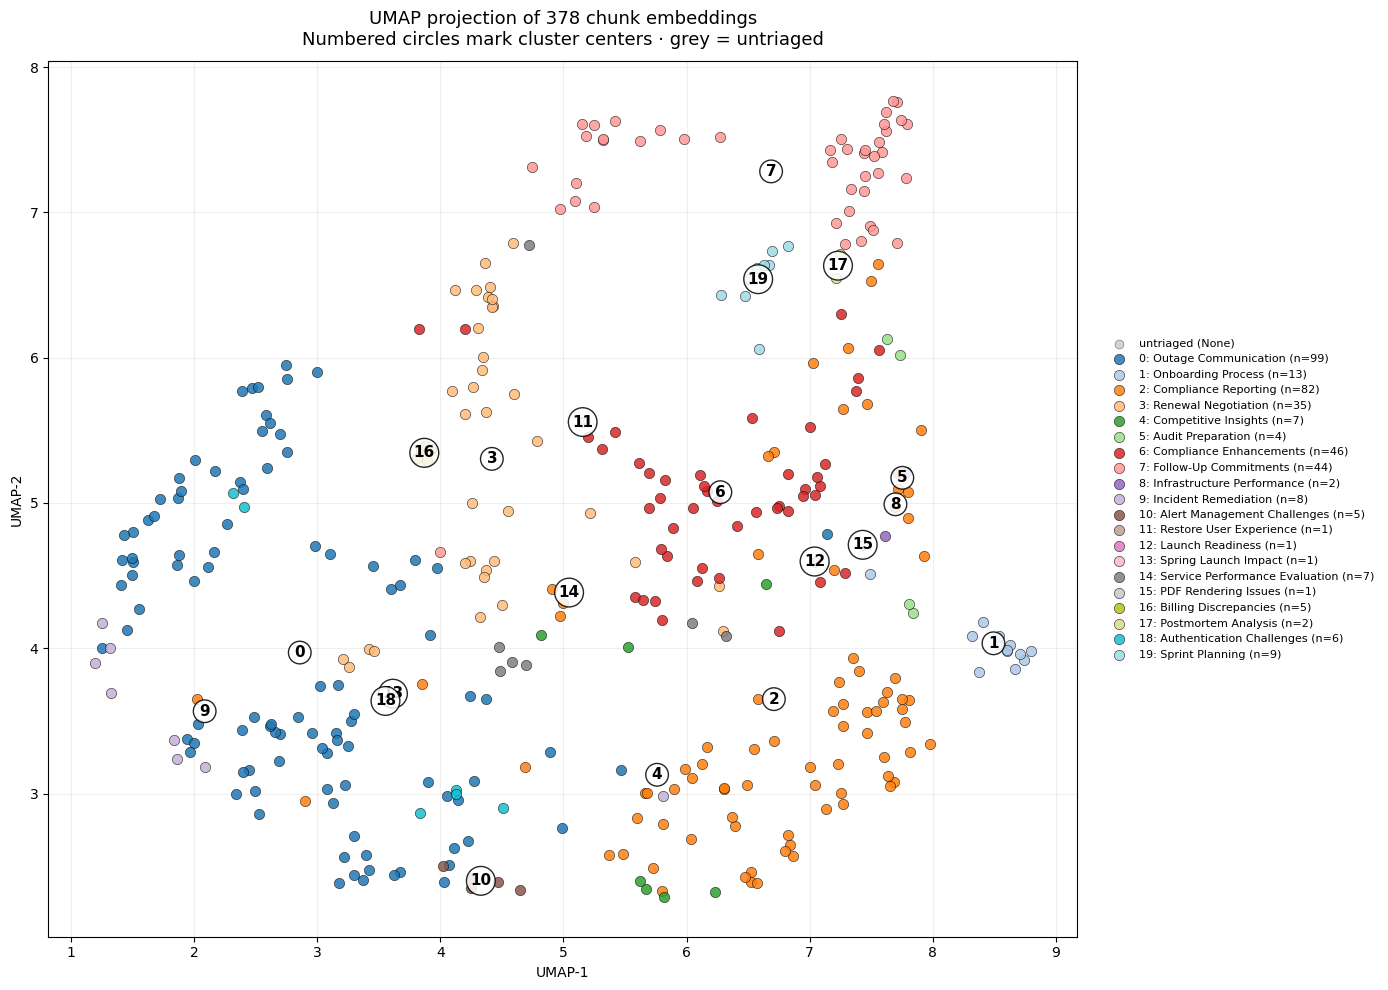

In [120]:
# pip install umap-learn
import umap

valid_rows = []
embs = []
for idx, e in zip(df.index, df["embedding"]):
    arr = np.asarray(e, dtype=np.float64)
    if arr.ndim == 1 and np.all(np.isfinite(arr)) and np.linalg.norm(arr) > 0:
        embs.append(arr)
        valid_rows.append(idx)
embs = np.stack(embs)
print(f"Projecting {embs.shape[0]} embeddings of dim {embs.shape[1]} to 2D...")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
coords = reducer.fit_transform(embs)

proj = df.loc[valid_rows].copy()
proj["x"] = coords[:, 0]
proj["y"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(14, 10))

untri = proj[proj["cluster_id"].isna()]
ax.scatter(untri["x"], untri["y"], s=40, c="lightgrey",
           edgecolor="grey", linewidth=0.5, label="untriaged (None)", zorder=1)

cluster_ids = sorted(proj["cluster_id"].dropna().unique())
cmap = plt.cm.tab20(np.linspace(0, 1, len(cluster_ids)))

for color, cid in zip(cmap, cluster_ids):
    sub = proj[proj["cluster_id"] == cid]
    cname = sub["cluster_name"].iloc[0]
    ax.scatter(sub["x"], sub["y"], s=55, color=color,
               edgecolor="black", linewidth=0.4, alpha=0.85,
               label=f"{int(cid)}: {cname} (n={len(sub)})", zorder=2)
    cx, cy = sub["x"].mean(), sub["y"].mean()
    ax.annotate(f"{int(cid)}", (cx, cy), fontsize=11, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.25",
                          facecolor="white", edgecolor="black", alpha=0.85),
                zorder=3)

ax.set_title(f"UMAP projection of {len(proj)} chunk embeddings\n"
             "Numbered circles mark cluster centers · grey = untriaged",
             fontsize=13, pad=12)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [122]:
SELECTED_CLUSTER_ID = 0
TOP_N = 3
WRAP_WIDTH = 90

full_cluster_df = df[df["cluster_id"] == SELECTED_CLUSTER_ID].copy()

cluster_df = (
    full_cluster_df
    .drop_duplicates(subset=["meeting_id"])
    .reset_index(drop=True)
)

cluster_name = cluster_df["cluster_name"].iloc[0]
print("=" * 80)
print(f"CLUSTER {SELECTED_CLUSTER_ID}: {cluster_name}")
print("=" * 80)

for idx, row in cluster_df.head(TOP_N).iterrows():
    print(f"\n--- Example {idx + 1}  ·  meeting_id: {row['meeting_id']}")
    print(f"chunk_label: {row['chunk_label']}")
    print("chunk_summary:")
    print(textwrap.fill(str(row["chunk_summary"]), width=WRAP_WIDTH))

CLUSTER 0: Outage Communication

--- Example 1  ·  meeting_id: 01KQ03B0303900521BB089CA
chunk_label: Outage Overview
chunk_summary:
Team discusses current outage status and need for remediation plan.

--- Example 2  ·  meeting_id: 01KQ0C1280EDA4E70AAD7C35
chunk_label: Migration Cleanup
chunk_summary:
Agent investigates provisioning logs and identifies undeprovisioned migration test
accounts as the source of the seat overage.

--- Example 3  ·  meeting_id: 01KQ0F8AFF3DA34FD4580008
chunk_label: Detect Outage Review
chunk_summary:
Discussion on March outage impact and remediation steps taken.


In [123]:
SELECTED_CLUSTER_ID = 16
TOP_N = 3
WRAP_WIDTH = 90

full_cluster_df = df[df["cluster_id"] == SELECTED_CLUSTER_ID].copy()

cluster_df = (
    full_cluster_df
    .drop_duplicates(subset=["meeting_id"])
    .reset_index(drop=True)
)

cluster_name = cluster_df["cluster_name"].iloc[0]
print("=" * 80)
print(f"CLUSTER {SELECTED_CLUSTER_ID}: {cluster_name}")
print("=" * 80)

for idx, row in cluster_df.head(TOP_N).iterrows():
    print(f"\n--- Example {idx + 1}  ·  meeting_id: {row['meeting_id']}")
    print(f"chunk_label: {row['chunk_label']}")
    print("chunk_summary:")
    print(textwrap.fill(str(row["chunk_summary"]), width=WRAP_WIDTH))

CLUSTER 16: Billing Discrepancies

--- Example 1  ·  meeting_id: 01KQ0C1280EDA4E70AAD7C35
chunk_label: Billing Discrepancy
chunk_summary:
Customer questions unexpected invoice overage after contract renewal.

--- Example 2  ·  meeting_id: 01KQ1DC6CA536DE1B31ED8F5
chunk_label: Billing Discrepancy
chunk_summary:
Customer raises concerns about unexpected overage charges on invoices.

--- Example 3  ·  meeting_id: 01KQ56AA6B60801ABC01AB1C
chunk_label: Billing Discrepancy
chunk_summary:
Customer raises concerns about unexpected overage charges on April invoice.


In [124]:
from sklearn.metrics.pairwise import cosine_similarity

SELECTED_CLUSTER_ID = 0
TOP_N = 3
WRAP_WIDTH = 90

cluster_df = (
    df[df["cluster_id"] == SELECTED_CLUSTER_ID]
    .copy()
    .reset_index(drop=True)
)

embeddings = np.vstack(cluster_df["embedding"].values)
centroid = embeddings.mean(axis=0).reshape(1, -1)
similarities = cosine_similarity(embeddings, centroid).flatten()
cluster_df["similarity_to_centroid"] = similarities

worst_examples = (
    cluster_df
    .sort_values("similarity_to_centroid", ascending=True)
    .drop_duplicates(subset=["meeting_id"])
    .head(TOP_N)
)

cluster_name = cluster_df["cluster_name"].iloc[0]
print("=" * 80)
print(f"WORST-FIT EXAMPLES · CLUSTER {SELECTED_CLUSTER_ID}: {cluster_name}")
print("=" * 80)

for idx, row in worst_examples.iterrows():
    print(f"\n--- Example {idx + 1}  ·  meeting_id: {row['meeting_id']}")
    print(f"chunk_label: {row['chunk_label']}")
    print("chunk_summary:")
    print(textwrap.fill(str(row["chunk_summary"]), width=WRAP_WIDTH))
    print(f"similarity_to_centroid: {row['similarity_to_centroid']:.4f}")

WORST-FIT EXAMPLES · CLUSTER 0: Outage Communication

--- Example 32  ·  meeting_id: 01KQ3C837D7EF689408DCF95
chunk_label: Backup Job Failure
chunk_summary:
Customer reports backup jobs failing with a 403 error after S3 connector setup.
similarity_to_centroid: 0.6755

--- Example 4  ·  meeting_id: 01KQ0C1280EDA4E70AAD7C35
chunk_label: Migration Cleanup
chunk_summary:
Agent investigates provisioning logs and identifies undeprovisioned migration test
accounts as the source of the seat overage.
similarity_to_centroid: 0.7224

--- Example 75  ·  meeting_id: 01KQADC32D89E2B76B698E84
chunk_label: Workaround Discussion
chunk_summary:
Agent suggests admin override for local authentication as a temporary fix.
similarity_to_centroid: 0.7244


/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [125]:


pio.renderers.default = "browser"

cluster_similarity_data = []

for cluster_id in sorted(df["cluster_id"].dropna().unique()):
    cluster_df = df[df["cluster_id"] == cluster_id].copy()
    if len(cluster_df) < 2:
        continue
    embeddings = np.vstack(cluster_df["embedding"].values)
    similarity_matrix = cosine_similarity(embeddings)
    similarities = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
    cluster_name = cluster_df["cluster_name"].iloc[0]
    cluster_label = f"{int(cluster_id)} · {cluster_name}"
    for sim in similarities:
        cluster_similarity_data.append({
            "cluster_id":    int(cluster_id),
            "cluster_name":  cluster_name,
            "cluster_label": cluster_label,
            "similarity":    sim,
        })

similarity_df = pd.DataFrame(cluster_similarity_data)

cluster_order = (
    similarity_df
    .groupby("cluster_label")["similarity"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig = px.box(
    similarity_df,
    x="cluster_label", y="similarity",
    points="outliers",
    category_orders={"cluster_label": cluster_order},
    title="Intra-Cluster Semantic Similarity Distribution",
)
fig.update_layout(
    width=1500, height=750,
    xaxis_title="Cluster ID · Cluster Name",
    yaxis_title="Cosine Similarity",
    showlegend=False,
    template="plotly_white",
)
fig.update_xaxes(tickangle=60)
fig.show()

/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study

In [132]:


pio.renderers.default = "browser"

TOP_TRANSCRIPTS = 12
TOP_THEMES = 8

sankey_df = df.dropna(subset=["meeting_id", "cluster_name"]).copy()

links_df = (
    sankey_df
    .groupby(["meeting_id", "cluster_name"])
    .size()
    .reset_index(name="chunk_count")
)

top_transcripts = sankey_df["meeting_id"].value_counts().head(TOP_TRANSCRIPTS).index
top_themes = sankey_df["cluster_name"].value_counts().head(TOP_THEMES).index

links_df = links_df[
    links_df["meeting_id"].isin(top_transcripts)
    & links_df["cluster_name"].isin(top_themes)
].copy()

transcript_nodes = links_df["meeting_id"].unique().tolist()
theme_nodes = links_df["cluster_name"].unique().tolist()
nodes = transcript_nodes + theme_nodes
node_index = {node: i for i, node in enumerate(nodes)}

sources = links_df["meeting_id"].map(node_index).tolist()
targets = links_df["cluster_name"].map(node_index).tolist()
values = links_df["chunk_count"].tolist()

theme_palette = [
    "#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51",
    "#8E44AD", "#3498DB", "#16A085", "#D35400", "#C0392B",
]
theme_color_map = {t: theme_palette[i % len(theme_palette)] for i, t in enumerate(theme_nodes)}

def hex_to_rgba(hex_color, alpha=0.45):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

node_colors = (
    ["rgba(160,160,160,0.85)"] * len(transcript_nodes)
    + [theme_color_map[t] for t in theme_nodes]
)
link_colors = [hex_to_rgba(theme_color_map[links_df.iloc[i]["cluster_name"]]) for i in range(len(links_df))]

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=18, thickness=18, line=dict(width=0.5, color="black"),
              label=nodes, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
))
fig.update_layout(
    title_text="Transcript-to-Theme Mapping",
    width=1500, height=850, font_size=13,
    paper_bgcolor="white", plot_bgcolor="white",
)
fig.show()

python(84135) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:


pio.renderers.default = "browser"

theme_size_df = (
    df.dropna(subset=["cluster_id", "cluster_name"])
    .groupby(["cluster_id", "cluster_name"])
    .agg(chunk_count=("chunk_id", "count"), transcript_count=("meeting_id", "nunique"))
    .reset_index()
    .sort_values("chunk_count", ascending=True)
)
theme_size_df["cluster_label"] = (
    theme_size_df["cluster_id"].astype(int).astype(str) + " · " + theme_size_df["cluster_name"]
)

fig = px.bar(
    theme_size_df, x="chunk_count", y="cluster_label",
    orientation="h", text="chunk_count",
    title="Discovered Business Themes by Chunk Count",
    hover_data={"cluster_id": True, "cluster_name": True,
                "chunk_count": True, "transcript_count": True, "cluster_label": False},
)
fig.update_traces(textposition="outside")
fig.update_layout(
    width=1200, height=800, template="plotly_white",
    xaxis_title="Number of Chunks", yaxis_title="Cluster ID · Theme", showlegend=False,
)
fig.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

cluster_centroids = (
    df.groupby(["cluster_id", "cluster_name"])["embedding"]
    .apply(lambda x: np.mean(np.vstack(x), axis=0))
    .reset_index()
)
cluster_centroids["cluster_label"] = (
    cluster_centroids["cluster_id"].astype(int).astype(str)
    + " · "
    + cluster_centroids["cluster_name"]
)

labels = cluster_centroids["cluster_label"].tolist()
X = np.vstack(cluster_centroids["embedding"].values)
Z = linkage(X, method="ward", metric="euclidean")

plt.figure(figsize=(16, 8))
dendrogram(Z, labels=labels, leaf_rotation=75, leaf_font_size=10)
plt.title("Hierarchical Relationship Between Discovered Themes")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [127]:
pio.renderers.default = "browser"

top10_cids = (
    df.dropna(subset=["cluster_id"])
      .groupby("cluster_id").size()
      .sort_values(ascending=False).head(10)
      .index.tolist()
)

topic_counts = Counter()
for topics in df["matched_provided_topics"]:
    for t in (topics or []):
        topic_counts[t] += 1

TOP_N_TOPICS = 15
top_topics = [t for t, _ in topic_counts.most_common(TOP_N_TOPICS)]
top_topics_set = set(top_topics)

flows = Counter()
for _, row in df[df["cluster_id"].isin(top10_cids)].iterrows():
    cid = row["cluster_id"]
    topics = row["matched_provided_topics"] or []
    if not topics:
        flows[(cid, "(no topic)")] += 1
        continue
    for t in topics:
        flows[(cid, t if t in top_topics_set else "other")] += 1

left_labels = [
    f"[{int(cid)}] {df[df['cluster_id']==cid]['cluster_name'].iloc[0]} "
    f"(n={(df['cluster_id']==cid).sum()})"
    for cid in top10_cids
]
right_topic_set = sorted({t for (_, t) in flows.keys()})
right_ordered = [t for t in top_topics if t in right_topic_set]
for extra in ["other", "(no topic)"]:
    if extra in right_topic_set:
        right_ordered.append(extra)

all_labels = left_labels + right_ordered
left_idx = {cid: i for i, cid in enumerate(top10_cids)}
right_idx = {t: len(left_labels) + i for i, t in enumerate(right_ordered)}

sources, targets, values = [], [], []
for (cid, topic), count in flows.items():
    sources.append(left_idx[cid])
    targets.append(right_idx[topic])
    values.append(count)

cluster_colors = px.colors.qualitative.Set3[:len(top10_cids)]
node_colors = cluster_colors + ["#cccccc"] * len(right_ordered)
link_colors = [
    cluster_colors[left_idx[cid]].replace("rgb", "rgba").replace(")", ",0.4)")
    if cluster_colors[left_idx[cid]].startswith("rgb") else "rgba(150,150,150,0.4)"
    for (cid, _) in flows.keys()
]

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=15, thickness=20,
              line=dict(color="black", width=0.5),
              label=all_labels, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
))
fig.update_layout(
    title_text=f"Cluster → Topic flow  ·  top 10 clusters ↔ top {TOP_N_TOPICS} provided topics",
    font=dict(size=11), height=700,
    margin=dict(l=20, r=20, t=60, b=20),
)

out_path = BASE_DIR / "sankey_cluster_topic.html"
fig.write_html(str(out_path))
print(f"Saved: {out_path}")
import webbrowser
webbrowser.open(str(out_path))

Saved: /Users/swatithapaswatithapa/Documents/study/transcript-mining/sankey_cluster_topic.html


True

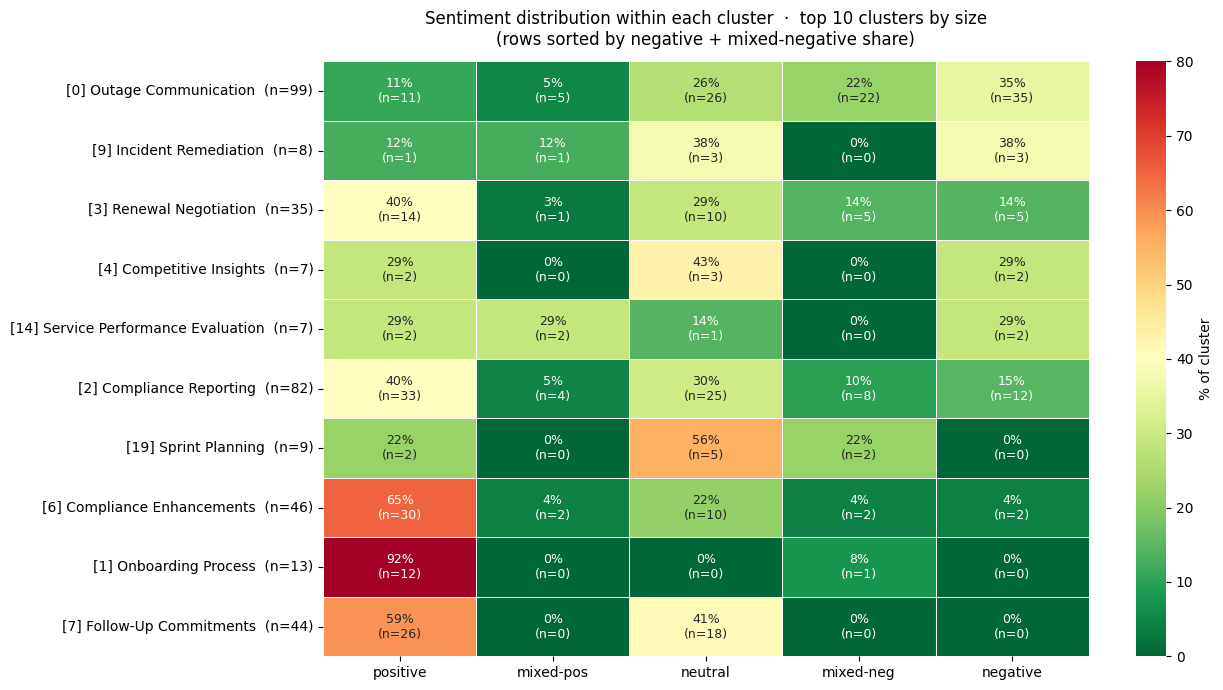

In [126]:
top10_ids = (
    df.dropna(subset=["cluster_id"])
      .groupby("cluster_id").size()
      .sort_values(ascending=False).head(10)
      .index.tolist()
)
sub = df[df["cluster_id"].isin(top10_ids)].copy()

SENTIMENT_MAP = {
    "very-negative":  "negative",
    "negative":       "negative",
    "mixed-negative": "mixed-neg",
    "neutral":        "neutral",
    "mixed-positive": "mixed-pos",
    "positive":       "positive",
    "very-positive":  "positive",
}
SENTIMENT_ORDER = ["positive", "mixed-pos", "neutral", "mixed-neg", "negative"]
sub["sentiment_bucket"] = sub["chunk_sentiment"].map(SENTIMENT_MAP)

ct = pd.crosstab(sub["cluster_id"], sub["sentiment_bucket"])
ct = ct.reindex(columns=SENTIMENT_ORDER, fill_value=0)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

sizes = sub.groupby("cluster_id").size()
names = sub.groupby("cluster_id")["cluster_name"].first()
row_labels = [f"[{int(cid)}] {names[cid]}  (n={int(sizes[cid])})" for cid in pct.index]
pct.index = row_labels
ct.index = row_labels

pct["_neg_score"] = pct["negative"] + pct["mixed-neg"]
pct = pct.sort_values("_neg_score", ascending=False).drop(columns="_neg_score")
ct = ct.loc[pct.index]

annot = pct.copy().astype(object)
for r in pct.index:
    for c in pct.columns:
        annot.at[r, c] = f"{pct.at[r,c]:.0f}%\n(n={int(ct.at[r,c])})"

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    pct, ax=ax,
    cmap="RdYlGn_r", vmin=0, vmax=80,
    annot=annot, fmt="",
    annot_kws={"size": 9},
    cbar_kws={"label": "% of cluster"},
    linewidths=0.5, linecolor="white",
)
ax.set_title("Sentiment distribution within each cluster  ·  top 10 clusters by size\n"
             "(rows sorted by negative + mixed-negative share)",
             fontsize=12, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()